In [10]:
import pymysql
import os
import pandas as pd
import datetime as dt
import pytz
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy


pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [11]:
#Connection to  MySQL server, parameters must be filled with correct information otherwise it won't work
conn = pymysql.connect(
    host = '127.0.0.1',
    user = 'root',
    password =  os.getenv("PASSWORD_MY_SQL"),
    database = 'data'
    )
cursor = conn.cursor()

# Preparing all addresses

In [12]:
#Extracting addresses with assigned timezone
sql = """SELECT eh.entity, eh.address, sd.timezone, sd.offsset FROM entities_heur as eh
    LEFT JOIN scraped_data as sd ON eh.entity = sd.entity
    LEFT JOIN exchanges_detection as ed on sd.id = ed.id
    WHERE sd.address is not null 
        and sd.location is not null 
        and sd.num_txs > 0 
        and sd.timezone is not null 
        and ed.arkham_entity is null 
        and (ed.arkham_label is null or ed.arkham_label = "Miner");"""
cursor.execute(sql)
data = cursor.fetchall()
len(data)

130214

In [13]:
data = pd.DataFrame(data, columns = ["entity", "address", "timezone", "offset"])
data.head()

,entity,address,timezone,offset
0,Entity 2436,121iyz8ZHtSNHX3mVTHzxztQ33cueBVEu5,Europe/Stockholm,1.0
1,Entity 2436,12418afg3GhCD56oHS5j9f2GzbcbP5oHjY,Europe/Stockholm,1.0
2,Entity 2436,12BmH6NTySEgudTSCYUbPtbn3tLtYyeWYg,Europe/Stockholm,1.0
3,Entity 2436,12DwYSkSw5H6twHcvGDu2tu3ZakdTFShB2,Europe/Stockholm,1.0
4,Entity 2436,12GmdvZKwPpdfRumDakRgJg2rcUG9T3inQ,Europe/Stockholm,1.0


In [14]:
data = data[~data["offset"].isna()]
len(data)

130214

In [15]:
#Transforming address to list and deleting duplicates
addresses = data["address"]
addresses = addresses.drop_duplicates()
addresses = addresses.tolist()

# Getting transaction data

In [16]:
#Getting all outgoing transaction to addresses from list
placeholders = ','.join(['%s'] * len(addresses))

query = f"""SELECT DISTINCT ti.txid, ti.input_order, ti.address, bd.mempool_entry_time, bd.fee, bd.num_inputs, bd.num_outputs, ti.value FROM tx_inputs AS ti
LEFT JOIN blockchain_data AS bd on ti.txid = bd.txid
WHERE address in ({placeholders});"""

cursor.execute(query, addresses)
database = cursor.fetchall()
database = pd.DataFrame(database, columns = ["txid", "input_order", "address", "mempool_entry_time", "fee", "num_inputs", "num_outputs", "value"])
database.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373
2,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,1,18rnnk2vr58dV9dHsxMFbRhyZ8NVFBNo2o,2014-12-20 15:31:40,22.831050,2,2,0.999900
3,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024
4,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,1,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.158314


In [20]:
#Merging transaction data to addresses to obtain entity identification number
db_final = database.merge(
    data,
    how = "left",
    on = "address"
)
db_final.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 1940,Europe/Kyiv,2.0
2,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 472,Asia/Kolkata,5.5
3,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 2162,Africa/Johannesburg,2.0
4,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 504,Asia/Kuching,8.0


In [23]:
#Creating help variable with adjusted time to UTC +0:00
db_final["time_adjusted"] = db_final.apply(
    lambda r: r["mempool_entry_time"] + pd.Timedelta(hours = r["offset"]),
    axis = 1
)
db_final = db_final.drop_duplicates(subset = ["txid"])
db_final.head()

/tmp/ipykernel_458362/37489651.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  lambda r: r["mempool_entry_time"] + pd.Timedelta(hours = r["offset"]),


,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,time_adjusted
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0,2020-09-06 04:41:07
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 1940,Europe/Kyiv,2.0,2014-12-20 17:31:40
11,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024,Entity 505,Asia/Manila,8.0,2015-11-26 21:20:49
13,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 20:19:07,34.793774,1,2,0.285407,Entity 70,Europe/Kyiv,2.0,2016-05-15 22:19:07
14,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 00:59:42,389.105058,1,2,0.107424,Entity 2090,Asia/Tokyo,9.0,2017-08-17 09:59:42


In [24]:
len(db_final)

324521

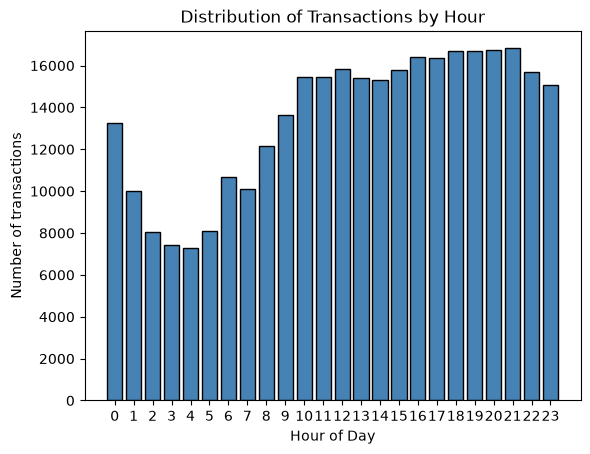

In [90]:
#General  graph of transaction activity tranformed to UTC +0:00
counts, bins, patches = plt.hist(db_final["time_adjusted"].dt.hour, bins=np.arange(25), 
                                 rwidth=0.8, color='steelblue', edgecolor='black')

plt.xticks(np.arange(24) + 0.5, labels=range(24))

plt.title("Distribution of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of transactions")

plt.show()

# Creating aggregated dataset with relative values 

In [27]:
#Extracting only hour of transaction from dataset
db_final["hour"] = pd.to_datetime(db_final["mempool_entry_time"]).dt.hour

/tmp/ipykernel_458362/2544582762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  db_final["hour"] = pd.to_datetime(db_final["mempool_entry_time"]).dt.hour


In [28]:
#Aggregation of transaction into entities
pivot = (
    db_final.pivot_table(
        index=["entity", "offset"],
        columns="hour",
        values="txid",
        aggfunc="count",
        fill_value=0
    )
)

In [29]:
pivot.head()

,hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
entity,offset,,,,,,,,,,,,,,,,,,,,,,,,
Entity 100,7.0,4,8,5,11,11,13,7,12,11,10,10,16,8,7,12,12,14,26,8,3,2,3,0,2
Entity 1000,2.0,5,5,3,1,0,1,2,0,1,1,4,1,2,2,0,0,0,1,0,1,0,1,0,1
Entity 1001,2.0,1,1,2,2,3,3,5,9,2,1,1,1,0,2,0,0,0,1,0,0,0,0,0,0
Entity 1002,-5.0,2,3,0,0,0,0,0,0,0,0,0,0,1,1,2,3,6,1,2,0,3,2,1,5
Entity 1003,7.0,0,0,1,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [54]:
table = pivot.reset_index()
table.columns.name = None
table.head()

,entity,offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,Entity 100,7.0,4,8,5,11,11,13,7,12,11,10,10,16,8,7,12,12,14,26,8,3,2,3,0,2
1,Entity 1000,2.0,5,5,3,1,0,1,2,0,1,1,4,1,2,2,0,0,0,1,0,1,0,1,0,1
2,Entity 1001,2.0,1,1,2,2,3,3,5,9,2,1,1,1,0,2,0,0,0,1,0,0,0,0,0,0
3,Entity 1002,-5.0,2,3,0,0,0,0,0,0,0,0,0,0,1,1,2,3,6,1,2,0,3,2,1,5
4,Entity 1003,7.0,0,0,1,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [55]:
cols_to_sum = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
table["total"] = table[cols_to_sum].sum(axis = 1)
table["log_total"] = table["total"].apply(lambda r: np.log(r))

#Bayesian normalization of data 
alpha = 1
table[cols_to_sum] = (table[cols_to_sum] + alpha).div(table["total"] + 24*alpha, axis = 0)

In [56]:
table.head()

,entity,offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total
0,Entity 100,7.0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,0.054393,0.050209,0.046025,0.046025,0.071130,0.037657,0.033473,0.054393,0.054393,0.062762,0.112971,0.037657,0.016736,0.012552,0.016736,0.004184,0.012552,215,5.370638
1,Entity 1000,2.0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,0.017857,0.035714,0.035714,0.089286,0.035714,0.053571,0.053571,0.017857,0.017857,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,32,3.465736
2,Entity 1001,2.0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,0.172414,0.051724,0.034483,0.034483,0.034483,0.017241,0.051724,0.017241,0.017241,0.017241,0.034483,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,34,3.526361
3,Entity 1002,-5.0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.035714,0.035714,0.053571,0.071429,0.125000,0.035714,0.053571,0.017857,0.071429,0.053571,0.035714,0.107143,32,3.465736
4,Entity 1003,7.0,0.034483,0.034483,0.068966,0.068966,0.034483,0.034483,0.137931,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,5,1.609438


In [82]:
table = table[(table["total"] >= 15) & (table["total"] <= 10000)]
len(table)

1941

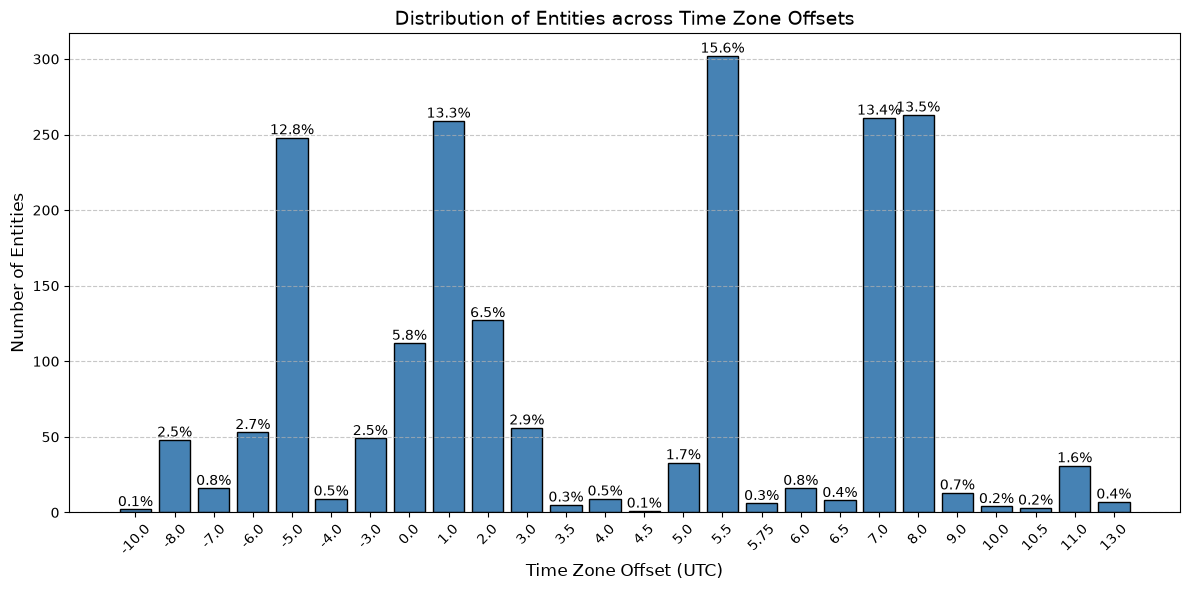

In [83]:
# 1. Count the occurrences of each offset 
offset_counts = table['offset'].value_counts().sort_index()

# Calculate the total number of entities to compute percentages
total_entities = len(table)

# 2. Set up the visualization using subplots for easier annotation control
fig, ax = plt.subplots(figsize=(12, 6))

# Create the bars and store them in a variable
bars = ax.bar(offset_counts.index.astype(str), offset_counts.values, color='steelblue', edgecolor='black')

# 3. Add the percentage labels on top of the columns
for bar in bars:
    count = bar.get_height()
    percentage = (count / total_entities) * 100
    
    # Place the text centered above each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position: middle of the bar
        count,                              # Y position: top of the bar
        f'{percentage:.1f}%',               # Text: formatted to 1 decimal place
        ha='center',                        # Horizontally center the text
        va='bottom',                        # Vertically align to the bottom of the text bounding box
        fontsize=10
    )

# 4. Add formatting and labels tailored to the data
plt.title('Distribution of Entities across Time Zone Offsets', fontsize=14)
plt.xlabel('Time Zone Offset (UTC)', fontsize=12)
plt.ylabel('Number of Entities', fontsize=12)

# Rotate the labels slightly in case the offset names get crowded
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Render the graph
plt.tight_layout()
plt.show()

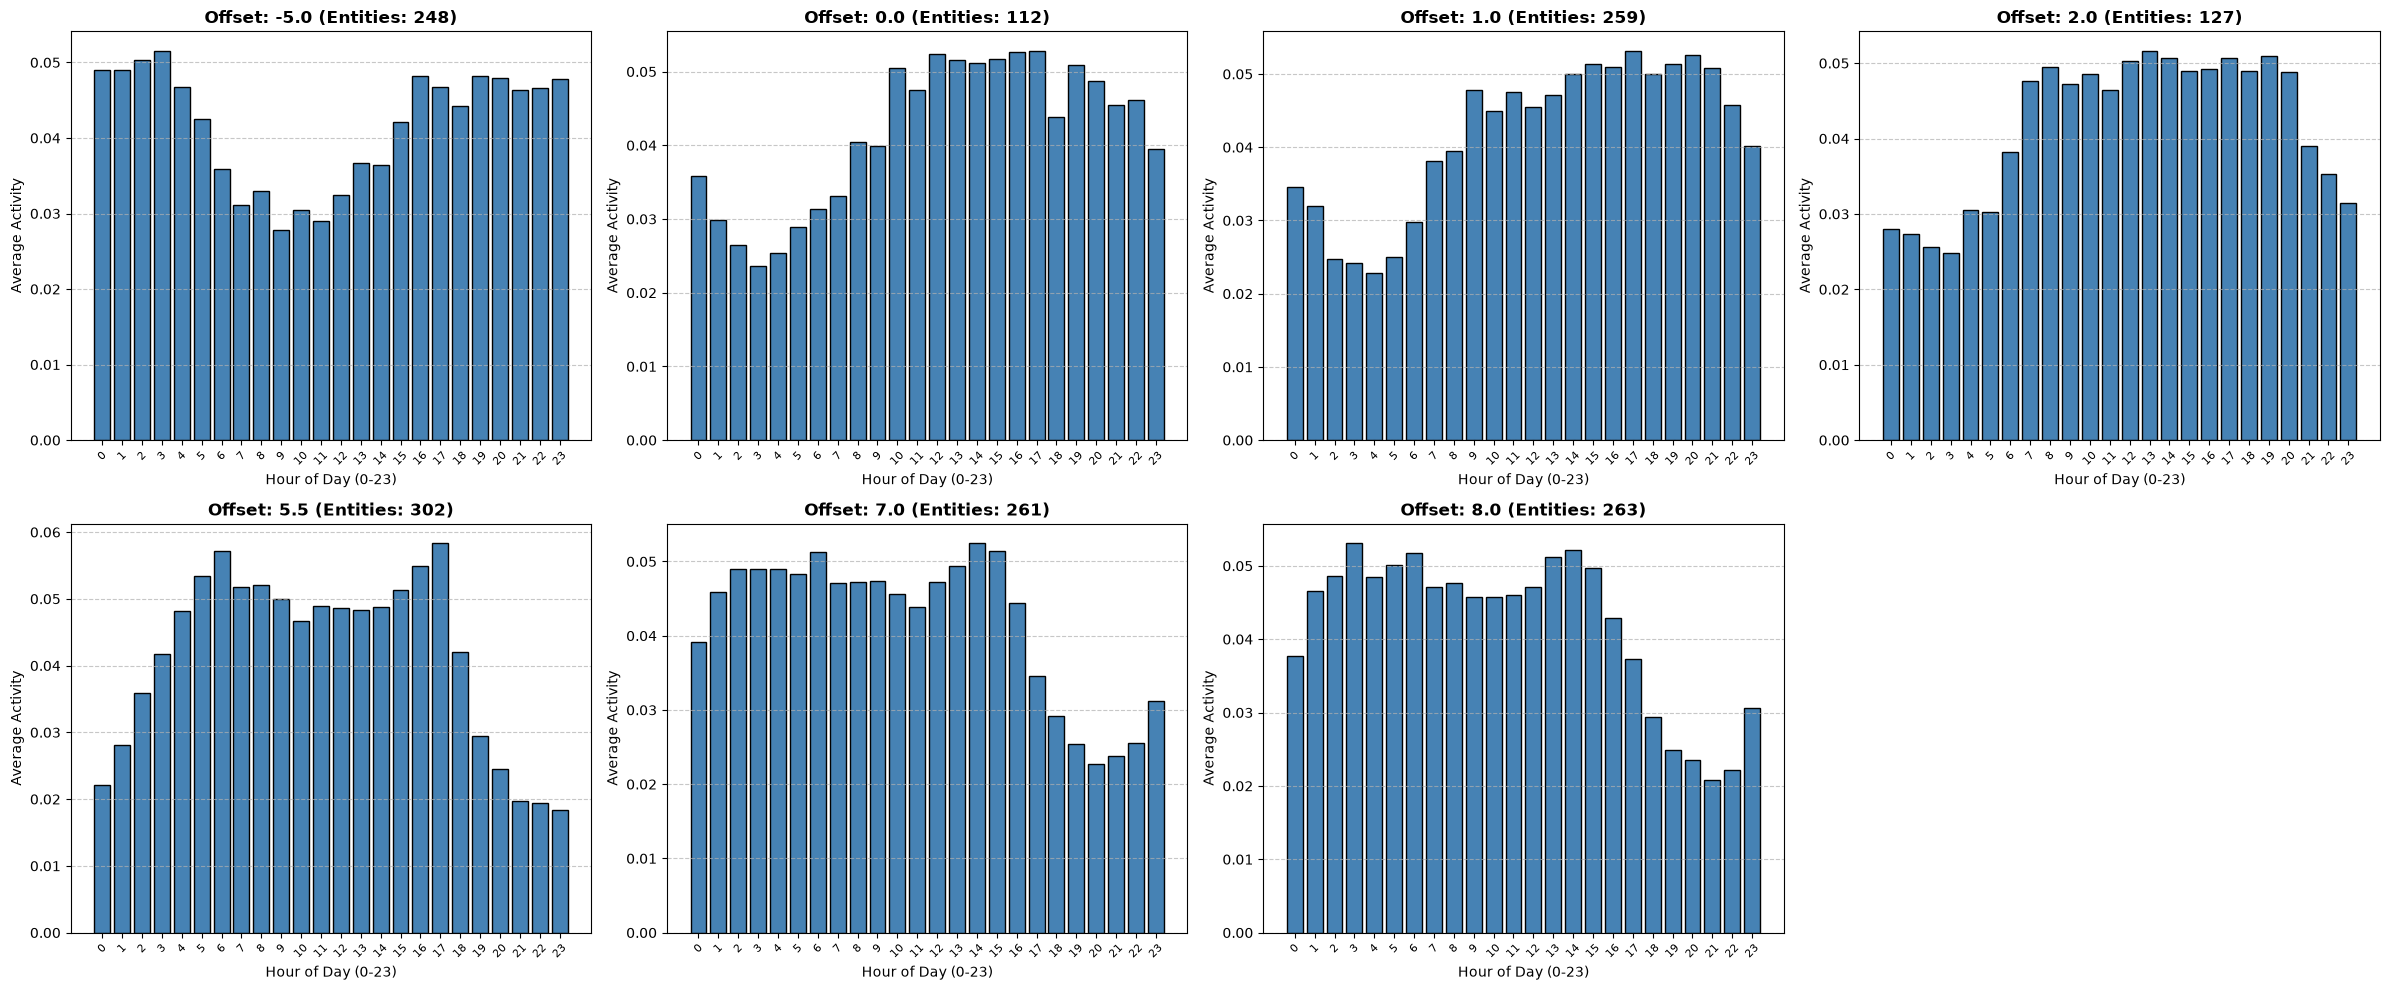

In [84]:
# 1. Find the top 7 largest offsets by entity count, then sort them by the offset value (smallest to largest)
top_7_offsets = table['offset'].value_counts().nlargest(7).sort_index()

# 2. Identify the hour columns (0 to 23)
activity_cols = [col for col in table.columns if str(col).isdigit() and 0 <= int(col) <= 23]
activity_cols = sorted(activity_cols, key=lambda x: int(x))

# 3. Create a single figure with a 2x4 grid (2 rows, 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easier looping

# 4. Loop through the sorted top 7 offsets and plot their average activity
for i, (offset_val, count) in enumerate(top_7_offsets.items()):
    ax = axes[i]
    
    # Filter data for the current offset
    subset = table[table['offset'] == offset_val]
    
    # Calculate the AVERAGE (mean) across the 0-23 columns
    avg_activity = subset[activity_cols].mean()
    
    # Plot as a bar chart to show the distribution
    ax.bar(avg_activity.index.astype(str), avg_activity.values, color='steelblue', edgecolor='black')
    
    # Add title with the offset value and the exact number of entities
    ax.set_title(f'Offset: {offset_val} (Entities: {count})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of Day (0-23)', fontsize=10)
    ax.set_ylabel('Average Activity', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Rotate x-axis labels to ensure they fit nicely in a 4-column layout
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# 5. Hide the 8th (unused) subplot since we only need 7 graphs
axes[7].set_visible(False)

# 6. Adjust spacing and render
plt.tight_layout()
plt.show()

# Creating regions

In [85]:
#Mapping and grouping data by defined regions
region_mapping = {
    # America
    -8.0: 'America', -7.0: 'America', -6.0: 'America', -5.0: 'America', -4.0: 'America', -3.0: 'America',
    
    # Euro-Africa
    0.0: 'Euro_Africa', 1.0: 'Euro_Africa', 2.0: 'Euro_Africa', 3.0: 'Euro_Africa',
    
    # Central Asia / India / Middle East
    3.5: 'Central_Asia', 4.0: 'Central_Asia', 4.5: 'Central_Asia', 5.0: 'Central_Asia', 
    5.5: 'Central_Asia', 5.75: 'Central_Asia', 6.0: 'Central_Asia', 6.5: 'Central_Asia',
    
    # East Asia / Pacific
    7.0: 'East_Asia_Pac', 8.0: 'East_Asia_Pac', 9.0: 'East_Asia_Pac', 10.0: 'East_Asia_Pac', 10.5: 'East_Asia_Pac', 11.0: 'East_Asia_Pac', 
    12.0: 'East_Asia_Pac', 13.0: 'East_Asia_Pac', -10.0: 'East_Asia_Pac', -9.0: 'East_Asia_Pac'
}

table['region'] = table['offset'].map(region_mapping)

In [86]:
table.head()

,entity,offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total,region,total_txs
0,Entity 100,7.0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,0.054393,0.050209,0.046025,0.046025,0.071130,0.037657,0.033473,0.054393,0.054393,0.062762,0.112971,0.037657,0.016736,0.012552,0.016736,0.004184,0.012552,215,5.370638,East_Asia_Pac,1.0
1,Entity 1000,2.0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,0.017857,0.035714,0.035714,0.089286,0.035714,0.053571,0.053571,0.017857,0.017857,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,32,3.465736,Euro_Africa,1.0
2,Entity 1001,2.0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,0.172414,0.051724,0.034483,0.034483,0.034483,0.017241,0.051724,0.017241,0.017241,0.017241,0.034483,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,34,3.526361,Euro_Africa,1.0
3,Entity 1002,-5.0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.035714,0.035714,0.053571,0.071429,0.125000,0.035714,0.053571,0.017857,0.071429,0.053571,0.035714,0.107143,32,3.465736,America,1.0
5,Entity 1004,7.0,0.017241,0.017241,0.017241,0.051724,0.086207,0.068966,0.086207,0.051724,0.017241,0.034483,0.086207,0.017241,0.103448,0.051724,0.017241,0.017241,0.051724,0.034483,0.068966,0.017241,0.034483,0.017241,0.017241,0.017241,34,3.526361,East_Asia_Pac,1.0


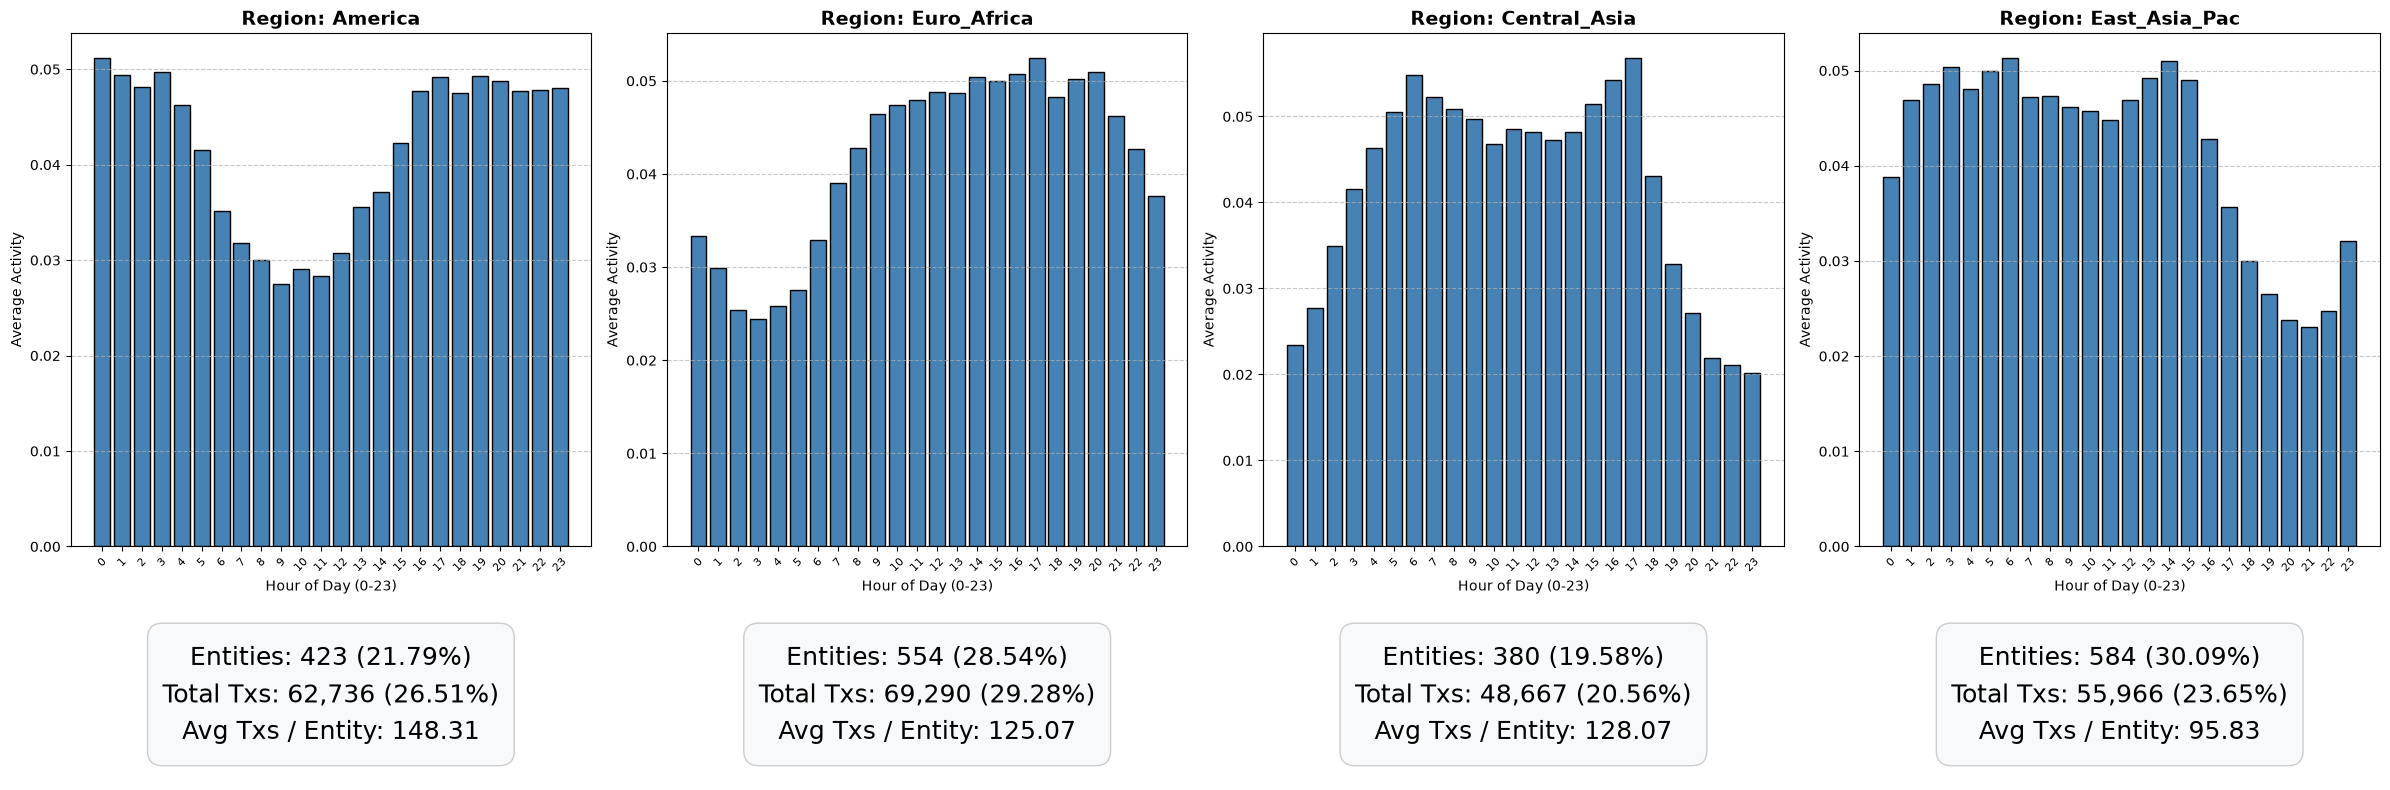

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. DATA PREPARATION & CALCULATIONS
# ---------------------------------------------------------

activity_cols = [col for col in table.columns if str(col).isdigit() and 0 <= int(col) <= 23]
activity_cols = sorted(activity_cols, key=lambda x: int(x))
total_entities_all = len(table)
total_txs_all = table['total'].sum()

summary_table = table.groupby('region').agg(
    number_of_entities=('entity', 'count'),
    number_of_txs=('total', 'sum')
).reset_index()

summary_table['avg_txs_per_entity'] = summary_table['number_of_txs'] / summary_table['number_of_entities']
summary_table['entity_percentage'] = (summary_table['number_of_entities'] / total_entities_all) * 100
summary_table['txs_percentage'] = (summary_table['number_of_txs'] / total_txs_all) * 100

summary_table = summary_table.round({'avg_txs_per_entity': 2, 'entity_percentage': 2, 'txs_percentage': 2})

# ---------------------------------------------------------
# 2. SPECIFY DESIRED REGION ORDER
# ---------------------------------------------------------

desired_order = ['America', 'Euro_Africa', 'Central_Asia', 'East_Asia_Pac']

# Filter to ensure only existing regions in the data are processed in order
regions_to_plot = [r for r in desired_order if r in table['region'].values]

# ---------------------------------------------------------
# 3. VISUALIZATION: HISTOGRAMS WITH STATS UNDERNEATH
# ---------------------------------------------------------

# Create 2 rows: Top row for Histograms, Bottom row for Region Stats
fig, axes = plt.subplots(
    nrows=2, 
    ncols=len(regions_to_plot), 
    figsize=(24, 8), 
    gridspec_kw={'height_ratios': [3, 1]}
)

for i, region in enumerate(regions_to_plot):
    ax_chart = axes[0, i]
    ax_stats = axes[1, i]
    
    # Filter data for current region
    subset = table[table['region'] == region]
    avg_activity = subset[activity_cols].mean()
    
    # Get summary statistics row for this region
    reg_stats = summary_table[summary_table['region'] == region].iloc[0]
    
    # --- TOP ROW: Histogram Plot ---
    ax_chart.bar(avg_activity.index.astype(str), avg_activity.values, color='steelblue', edgecolor='black')
    ax_chart.set_title(f'Region: {region}', fontsize=14, fontweight='bold')
    ax_chart.set_xlabel('Hour of Day (0-23)', fontsize=10)
    ax_chart.set_ylabel('Average Activity', fontsize=10)
    ax_chart.grid(axis='y', linestyle='--', alpha=0.7)
    ax_chart.tick_params(axis='x', rotation=45, labelsize=8)
    
    # --- BOTTOM ROW: Region Specific Stats ---
    ax_stats.axis('off')  # Hide axis ticks and box
    
    stats_text = (
        f"Entities: {int(reg_stats['number_of_entities']):,} ({reg_stats['entity_percentage']:.2f}%)\n"
        f"Total Txs: {int(reg_stats['number_of_txs']):,} ({reg_stats['txs_percentage']:.2f}%)\n"
        f"Avg Txs / Entity: {reg_stats['avg_txs_per_entity']:.2f}"
    )
    
    # Add formatted text box directly beneath the corresponding histogram
    ax_stats.text(
        0.5, 0.5, stats_text,
        transform=ax_stats.transAxes,
        fontsize=18,
        ha='center',
        va='center',
        linespacing=1.5,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#cccccc', linewidth=1)
    )

plt.tight_layout()
plt.show()

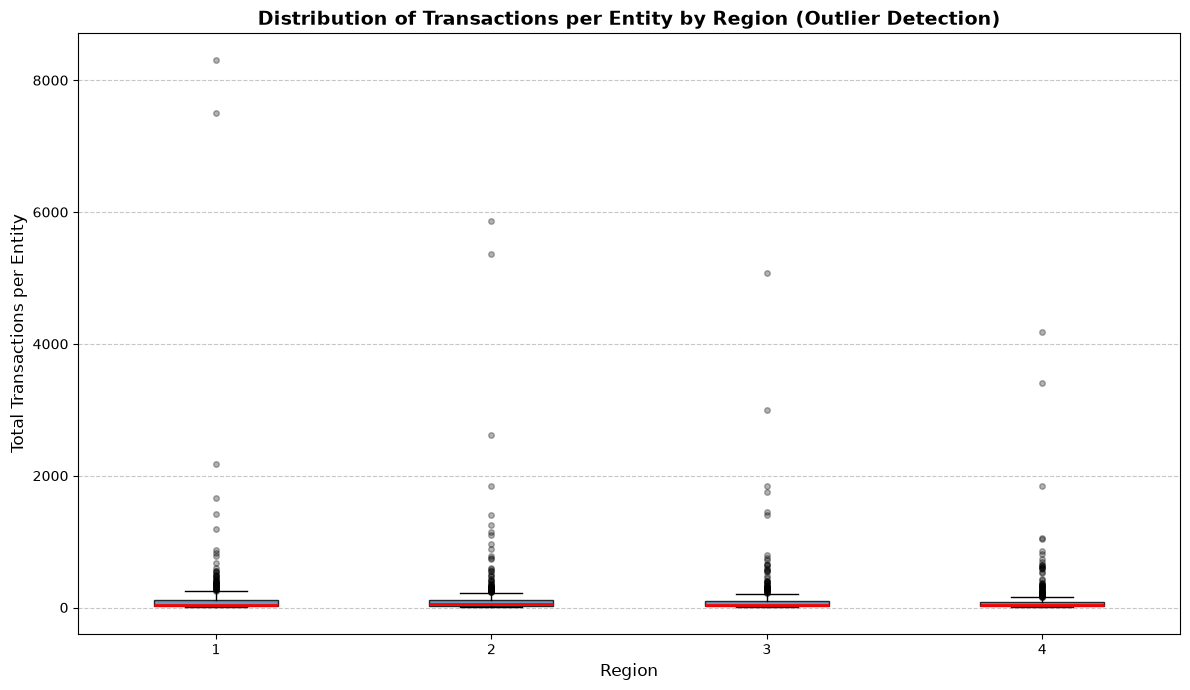

In [88]:
# Ensure we only try to plot regions that actually exist in the dataset
regions_to_plot = [r for r in desired_order if r in table['region'].values]

# Group the transaction data by region into a list of arrays for matplotlib
data_to_plot = [table[table['region'] == region]['total'] for region in regions_to_plot]

# Create the box plot figure
plt.figure(figsize=(12, 7))

# Plot the data
# - patch_artist=True allows us to fill the boxes with color
# - flierprops controls the appearance of the outlier markers (the dots)
plt.boxplot(
    data_to_plot, 
    label=regions_to_plot, 
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='black', alpha=0.8),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='black', markerfacecolor='black', alpha=0.3, markersize=4)
)

# Formatting and labels
plt.title('Distribution of Transactions per Entity by Region (Outlier Detection)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Transactions per Entity', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# OPTIONAL: LOG SCALE
# If extreme outliers make the main boxes unreadable, 
# uncomment the line below to view the data on a log scale:
# ---------------------------------------------------------
# plt.yscale('log')

plt.tight_layout()
plt.show()

In [89]:
table.to_csv("database_from_bitcointalk.csv")